# Ljungqvist & Sargent (2018), Chapter 8 --- Equilibrium with Complete Markets

Companion notebook to `ls_solutions_ch08.pdf`. Chapter 8 has **28 end-of-chapter exercises**
(printed pp. 304--330). One section per exercise. Every number in the PDF is computed here and checked
by an independent route with an `assert`: closed forms vs numerical optimisation (`scipy`), matrix
formulas ($(I-\beta P)^{-1}$, $Q^h$) vs brute-force enumeration of histories or truncated sums,
Arrow-security budget constraints state by state, Perron-root recovery vs a quadratic in $\beta$.

The LQ toolkit of `ls_ch05.ipynb`/`ls_ch07.ipynb` (`olrp`, `dare`, ...) is not used: no exercise in this
chapter is a linear-quadratic problem. The shared tools below are Markov-chain pricing helpers.
Where the book gives no numbers, the parameters chosen are stated in the section and in the PDF.

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar, brentq
from scipy.stats import binom

plt.rcParams.update({"pdf.fonttype": 42, "font.size": 10})  # TrueType, never Type 3
FIG = "fig/"
np.set_printoptions(precision=6, suppress=True, linewidth=110)


def kernel(beta, P, mu):
    """One-step Arrow pricing kernel (8.9.4): Q_ij = beta P_ij mu_j / mu_i.

    beta: discount factor; P (n,n) transition matrix; mu (n,) marginal utility of consumption by state
    (for growth economies, the marginal utility of the growth factor, see 8.4/8.6).
    """
    return beta * P * mu[None, :] / mu[:, None]


def hstep_rec(Q, h):
    """h-step kernel by the explicit double sum (8.10.3), no matrix product (independent of Q^h)."""
    n = Q.shape[0]
    Qh = Q.copy()
    for _ in range(h - 1):
        new = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                new[i, j] = sum(Q[i, k] * Qh[k, j] for k in range(n))
        Qh = new
    return Qh


def histories(P, s0, T):
    """Enumerate all histories (s_1..s_T) from s0 with their probabilities (8.9.1)."""
    n = P.shape[0]
    for h in itertools.product(range(n), repeat=T):
        pr, s = 1.0, s0
        for x in h:
            pr *= P[s, x]
            s = x
        yield h, pr


def stationary(P):
    """Stationary distribution: left unit eigenvector of P."""
    w, V = np.linalg.eig(P.T)
    v = np.real(V[:, np.argmin(abs(w - 1))])
    return v / v.sum()

## Exercise 8.1 --- Family economics, I

Planner: $\max\ \lambda_1\log c_1+\lambda_2(\log c_2-n_2)$ s.t. $c_1+c_2\le n_2+s$, $n_2\ge0$.
Interior ($s\le1+\lambda_1/\lambda_2$): $\theta=\lambda_2$, $c_1=\lambda_1/\lambda_2$, $c_2=1$, $n_2=1+\lambda_1/\lambda_2-s$.
Corner: $n_2=0$, $c_i=\lambda_is/(\lambda_1+\lambda_2)$, $\theta=(\lambda_1+\lambda_2)/s$.
Checks: `scipy` SLSQP on the planner; $\partial W/\partial s=\theta$ by finite differences; competitive consumers
at $p=w=1$ (person 1 owns $s$ and transfers $T=s-\lambda_1/\lambda_2$ to person 2; book misprint read as person 1 has no labour) reproduce the plan. Illustration $\lambda_1=1,\lambda_2=2$.

In [2]:
def family1_closed(l1, l2, s):
    """Exercise 8.1(b): Pareto allocation (c1, c2, n2) and multiplier theta."""
    if s <= 1 + l1 / l2:
        return l1 / l2, 1.0, 1 + l1 / l2 - s, l2
    return l1 * s / (l1 + l2), l2 * s / (l1 + l2), 0.0, (l1 + l2) / s


def family_num(l1, l2, feas):
    """Planner solved numerically; feas(c1, c2, n2) >= 0 is the resource constraint."""
    obj = lambda x: -(l1 * np.log(x[0]) + l2 * (np.log(x[1]) - x[2]))
    r = minimize(obj, [0.3, 0.3, 0.3], method="SLSQP", bounds=[(1e-9, None)] * 2 + [(0, None)],
                 constraints=[{"type": "ineq", "fun": lambda x: feas(*x)}], options={"ftol": 1e-14, "maxiter": 500})
    return r.x, -r.fun


l1, l2 = 1.0, 2.0
for s in (0.5, 3.0):
    c1, c2, n2, th = family1_closed(l1, l2, s)
    x, W = family_num(l1, l2, lambda a, b, n: n + s - a - b)
    assert np.allclose(x, [c1, c2, n2], atol=1e-5)
    dWds = (family_num(l1, l2, lambda a, b, n: n + s + 1e-4 - a - b)[1] - family_num(l1, l2, lambda a, b, n: n + s - 1e-4 - a - b)[1]) / 2e-4
    assert abs(dWds - th) < 1e-3
    print(f"s = {s}: c1 = {c1:.4f}, c2 = {c2:.4f}, n2 = {n2:.4f}, theta = {th:.4f} (dW/ds = {dWds:.4f})")

# (d)-(e) competitive: p = w = 1 (linear technology); person 1 owns s and transfers T = s - tau to person 2
s, tau = 0.5, l1 / l2
r2 = minimize(lambda x: -(np.log(x[0] + s - tau) - x[0]), [0.5], bounds=[(1e-9, None)])   # choose n2
n2 = r2.x[0]
assert np.isclose(n2, family1_closed(l1, l2, s)[2], atol=1e-5) and np.isclose(n2 + s - tau, 1, atol=1e-5)
print(f"competitive: person 1 owns s = {s}, transfers T = s - l1/l2 = {s - tau}; c1 = {tau}, c2 = {n2 + s - tau:.4f}, n2 = {n2:.4f}")

s = 0.5: c1 = 0.5000, c2 = 1.0000, n2 = 1.0000, theta = 2.0000 (dW/ds = 2.0000)
s = 3.0: c1 = 1.0000, c2 = 2.0000, n2 = 0.0000, theta = 1.0000 (dW/ds = 1.0000)
competitive: person 1 owns s = 0.5, transfers T = s - l1/l2 = 0.0; c1 = 0.5, c2 = 1.0000, n2 = 1.0000


## Exercise 8.2 --- Family economics, II

Resource constraint $c_1+c_2\le sn_2+1$. Interior ($s(1+\lambda_1/\lambda_2)\ge1$): $\theta=\lambda_2/s$, $c_2=s$,
$c_1=s\lambda_1/\lambda_2$, $n_2=1+\lambda_1/\lambda_2-1/s$. Corner: $n_2=0$, $c_i=\lambda_i/(\lambda_1+\lambda_2)$,
$\theta=\lambda_1+\lambda_2$. Competitive: $w=s$; consumer 2 (labour income $sn_2$ plus transfer $T$) chooses
$c_2=w=s$; consumer 1 owns the unit endowment and transfers $T=1-s\lambda_1/\lambda_2$ to consumer 2.

In [3]:
def family2_closed(l1, l2, s):
    """Exercise 8.2(b): Pareto allocation (c1, c2, n2) and multiplier theta."""
    if s * (1 + l1 / l2) >= 1:
        return s * l1 / l2, s, 1 + l1 / l2 - 1 / s, l2 / s
    return l1 / (l1 + l2), l2 / (l1 + l2), 0.0, l1 + l2


for s in (2.0, 0.5):
    c1, c2, n2, th = family2_closed(l1, l2, s)
    x, W = family_num(l1, l2, lambda a, b, n: s * n + 1 - a - b)
    assert np.allclose(x, [c1, c2, n2], atol=1e-5)
    dW = (family_num(l1, l2, lambda a, b, n: s * n + 1 + 1e-4 - a - b)[1] - family_num(l1, l2, lambda a, b, n: s * n + 1 - 1e-4 - a - b)[1]) / 2e-4
    assert abs(dW - th) < 1e-3
    print(f"s = {s}: c1 = {c1:.4f}, c2 = {c2:.4f}, n2 = {n2:.4f}, theta = {th:.4f}")

# competitive with w = s: consumer 1 keeps 1 - T, consumer 2 receives T and earns s n2
s = 2.0
c1, c2, n2, th = family2_closed(l1, l2, s)
T = 1 - c1                                 # consumer 1 consumes 1 - T
r2 = minimize(lambda x: -(np.log(s * x[0] + T) - x[0]), [0.5], bounds=[(0, None)])
assert np.isclose(r2.x[0], n2, atol=1e-5)
print(f"competitive: w = s = {s}, transfer 1 -> 2 T = {T:.4f}, n2 = {r2.x[0]:.4f}")
# (f) with no transfer (T = 0): n2 = 1 whatever s
for s in (0.5, 2.0, 7.0):
    r2 = minimize(lambda x: -(np.log(s * x[0]) - x[0]), [0.5], bounds=[(1e-9, None)])
    assert np.isclose(r2.x[0], 1.0, atol=1e-5)

s = 2.0: c1 = 1.0000, c2 = 2.0000, n2 = 1.0000, theta = 1.0000
s = 0.5: c1 = 0.3333, c2 = 0.6667, n2 = 0.0000, theta = 3.0000
competitive: w = s = 2.0, transfer 1 -> 2 T = 0.0000, n2 = 1.0000


## Exercise 8.3 --- Existence of a representative consumer

Illustration: $u=\log$, $w(c)=-1/c$ (CRRA 2), $\theta=.3$. Checks: $v_\theta'(c)=\theta u'(c_1)=(1-\theta)w'(c_2)$
(finite differences of the numerically maximised $v_\theta$), $v_\theta''<0$, and the implicit-function
formula $\partial c_1/\partial c\in(0,1)$.

In [4]:
th = 0.3
u, up, upp = np.log, lambda c: 1 / c, lambda c: -1 / c**2
w, wp, wpp = lambda c: -1 / c, lambda c: 1 / c**2, lambda c: -2 / c**3


def v_theta(c):
    """Representative consumer's utility: max over c1 of theta u(c1) + (1-theta) w(c - c1)."""
    r = minimize_scalar(lambda c1: -(th * u(c1) + (1 - th) * w(c - c1)), bounds=(1e-10, c - 1e-10),
                        method="bounded", options={"xatol": 1e-13})
    return -r.fun, r.x


for c in (0.5, 1.0, 2.0):
    v, c1 = v_theta(c)
    h = 1e-4
    vp = (v_theta(c + h)[0] - v_theta(c - h)[0]) / (2 * h)
    vpp = (v_theta(c + h)[0] - 2 * v + v_theta(c - h)[0]) / h**2
    dc1 = (1 - th) * wpp(c - c1) / (th * upp(c1) + (1 - th) * wpp(c - c1))
    assert np.isclose(vp, th * up(c1), rtol=1e-5) and np.isclose(vp, (1 - th) * wp(c - c1), rtol=1e-5)
    assert vpp < 0 and 0 < dc1 < 1
    assert np.isclose(vpp, th * upp(c1) * dc1, rtol=1e-2)
    print(f"c = {c}: c1 = {c1:.5f}, v' = {vp:.5f} = theta u'(c1) = {th*up(c1):.5f}, v'' = {vpp:.4f}")

c = 0.5: c1 = 0.07677, v' = 3.90788 = theta u'(c1) = 3.90788, v'' = -13.5510
c = 1.0: c1 = 0.24457, v' = 1.22663 = theta u'(c1) = 1.22663, v'' = -1.9712
c = 2.0: c1 = 0.71151, v' = 0.42164 = theta u'(c1) = 0.42164, v'' = -0.3110


## Exercise 8.4 --- Term structure of interest rates

$c_t=y_t$, $q^0_t(s^t)=\beta^t\pi_t(s^t)(y_t/y_0)^{-\gamma}$. With $\Lambda=\mathrm{diag}(\bar\lambda^{-\gamma})$ the
one-step kernel is $Q=\beta P\Lambda$, $Q_{ij}=\beta P_{ij}\bar\lambda_j^{-\gamma}$; contingent prices $Q^j$,
risk-free prices $Q^j\mathbf 1$ (row of $\lambda_0$). Check: brute-force enumeration over histories.

In [5]:
P4 = np.array([[.8, .2], [.15, .85]]); lam4 = np.array([.98, 1.03]); beta4, gam4 = .96, 2.0
pist = stationary(P4)
Eg_stat = pist @ lam4
Eg_1 = np.array([.5, .5]) @ P4 @ lam4
print(f"(c) stationary distribution {pist}, E[lambda] = {Eg_stat:.6f}; from pi0=[.5,.5]: E[lambda_1] = {Eg_1:.6f}")
assert np.allclose(pist @ P4, pist) and np.isclose(pist[0], 3 / 7)

Q4 = beta4 * P4 * lam4[None, :]**(-gam4)
print("Q =", Q4.round(6).tolist())
i0 = 0                                            # lambda_0 = .98 = state 1
rf = [np.linalg.matrix_power(Q4, j)[i0].sum() for j in range(3)]
c1_ = [np.linalg.matrix_power(Q4, j)[i0, 0] for j in range(3)]
c2_ = [np.linalg.matrix_power(Q4, j)[i0, 1] for j in range(3)]
# independent: enumerate histories
for j in range(3):
    tot, st = 0.0, np.zeros(2)
    for h, pr in histories(P4, i0, j):
        q = beta4**j * pr * np.prod(lam4[list(h)])**(-gam4)
        tot += q
        st[h[-1] if j else i0] += q
    assert np.isclose(tot, rf[j]) and np.allclose(st, [c1_[j], c2_[j]])
assert np.allclose(np.array(c1_) + np.array(c2_), rf)
for j in range(3):
    print(f"j = {j}: risk-free {rf[j]:.6f} | lambda_j = .98: {c1_[j]:.6f} | lambda_j = 1.03: {c2_[j]:.6f}"
          f" | yield {rf[j]**(-1/j) - 1 if j else float('nan'):.5f}")

(c) stationary distribution [0.428571 0.571429], E[lambda] = 1.008571; from pi0=[.5,.5]: E[lambda_1] = 1.006250
Q = [[0.799667, 0.180978], [0.149938, 0.769158]]
j = 0: risk-free 1.000000 | lambda_j = .98: 1.000000 | lambda_j = 1.03: 0.000000 | yield nan
j = 1: risk-free 0.980645 | lambda_j = .98: 0.799667 | lambda_j = 1.03: 0.180978 | yield 0.01974
j = 2: risk-free 0.950526 | lambda_j = .98: 0.666602 | lambda_j = 1.03: 0.283923 | yield 0.02569


## Exercise 8.5 --- Periodic endowments (period 3)

Aggregate endowment $\equiv1$ so $q^0_t=\beta^t$; $c^1=(1-\beta)\sum_t\beta^ty^1_t=1/(1+\beta+\beta^2)$,
$c^2=(\beta+\beta^2)/(1+\beta+\beta^2)$; the .05 perpetuity costs $.05/(1-\beta)$.
Illustration $\beta=.95$. Check: truncated sums ($T=3000$).

In [6]:
b5 = 0.95
t = np.arange(3000)
y1 = (t % 3 == 0).astype(float); y2 = 1 - y1
c1 = 1 / (1 + b5 + b5**2)
assert np.isclose(c1 * np.sum(b5**t), np.sum(b5**t * y1)) and np.isclose((1 - c1) * np.sum(b5**t), np.sum(b5**t * y2))
print(f"c1 = {c1:.6f}, c2 = {1-c1:.6f}, perpetuity price = {0.05/(1-b5):.4f} (ex-dividend {0.05*b5/(1-b5):.4f})")

c1 = 0.350570, c2 = 0.649430, perpetuity price = 1.0000 (ex-dividend 0.9500)


## Exercise 8.6 --- Mehra--Prescott endowment

$q^0_t(s^t)=\beta^t\pi_t(s^t)(d_t/d_0)^{-\gamma}$; one-step kernel $Q_{ij}=\beta P_{ij}\bar\lambda_j^{-\gamma}$
(units of time-$t$ good per unit of time-$t+1$ good); claim on the endowment: $d_tv(\lambda_t)$ with
$v=(I-\beta P\,\mathrm{diag}(\bar\lambda^{1-\gamma}))^{-1}\mathbf1$; these are also the natural debt limits
per unit of $d$. Checks: enumeration of all $2^5$ histories; truncated series vs inverse; Arrow
budget constraint at zero holdings.

In [7]:
P6 = np.array([[.8, .2], [.1, .9]]); lam6 = np.array([.97, 1.03]); b6, g6 = .95, 2.0
idx = {.97: 0, 1.03: 1}


def q_hist(hist, P, lam, beta, gam, s0=0):
    """Time-0 price of one unit at date len(hist) contingent on the growth history hist (list of values)."""
    pr, s, d = 1.0, s0, 1.0
    for x in hist:
        k = idx[x]; pr *= P[s, k]; s = k; d *= x
    return beta**len(hist) * pr * d**(-gam), pr, d


for hist in ([.97, .97, 1.03, .97, 1.03], [1.03, 1.03, 1.03, 1.03, .97]):
    q, pr, d5 = q_hist(hist, P6, lam6, b6, g6)
    print(f"history {hist}: prob = {pr:.6f}, d5 = {d5:.6f}, price = {q:.8f}")
qb, qc = q_hist([.97, .97, 1.03, .97, 1.03], P6, lam6, b6, g6)[0], q_hist([1.03] * 4 + [.97], P6, lam6, b6, g6)[0]
assert np.isclose(qb, b6**5 * .8 * .8 * .2 * .1 * .2 * (.97**3 * 1.03**2)**-2)

K6 = b6 * P6 * lam6[None, :]**(1 - g6)              # value of the endowment claim, per unit of current d
v6 = np.linalg.solve(np.eye(2) - K6, np.ones(2))
v6_series = sum(np.linalg.matrix_power(K6, j) @ np.ones(2) for j in range(4000))
assert np.allclose(v6, v6_series)
print(f"(d) price of claim on whole endowment (cum-dividend), per unit of d_0: v = {v6}  -> at lambda0 = .97: {v6[0]:.4f}")
Q6 = b6 * P6 * lam6[None, :]**(-g6)
e1 = np.linalg.matrix_power(Q6, 5)[0, 0]
e1_enum = sum(b6**5 * pr * np.prod(lam6[list(h)])**(-g6) for h, pr in histories(P6, 0, 5) if h[-1] == 0)
e1_div = np.linalg.matrix_power(K6, 5)[0, 0]      # claim on d_5 itself when lambda_5 = .97
assert np.isclose(e1, e1_enum)
print(f"(e) one unit at t=5 if lambda_5 = .97: {e1:.6f};  claim on d_5 if lambda_5 = .97: {e1_div:.6f}")
print("(h) one-step kernel Q =\n", Q6)
print(f"(i) one-period risk-free bond price: {Q6.sum(1)} ; two-period (pays at t+2): {(Q6 @ Q6).sum(1)}")
# Arrow budget with zero holdings: c + sum Q a' = y + a with c = y, a = 0 -> trivially; debt limit recursion
A6 = v6                                               # A(s)/d = 1 + sum_j Q_ij lam_j A(j)/1  (growth-adjusted)
assert np.allclose(A6, 1 + (Q6 * lam6[None, :]) @ A6)
print(f"(g) natural debt limits A(s^t) = d_t * {A6}")

history [0.97, 0.97, 1.03, 0.97, 1.03]: prob = 0.002560, d5 = 0.968255, price = 0.00211290
history [1.03, 1.03, 1.03, 1.03, 0.97]: prob = 0.014580, d5 = 1.091744, price = 0.00946530


(d) price of claim on whole endowment (cum-dividend), per unit of d_0: v = [18.933155 16.799465]  -> at lambda0 = .97: 18.9332
(e) one unit at t=5 if lambda_5 = .97: 0.440235;  claim on d_5 if lambda_5 = .97: 0.388790
(h) one-step kernel Q =
 [[0.807737 0.179093]
 [0.100967 0.80592 ]]
(i) one-period risk-free bond price: [0.98683  0.906887] ; two-period (pays at t+2): [0.959517 0.830515]
(g) natural debt limits A(s^t) = d_t * [18.933155 16.799465]


## Exercise 8.7 --- Two consumers, $y^1=s_t\in\{0,1\}$, $y^2=1$, log utility

$c^1=\theta Y(s)$, $q^0_t(s^t)=\beta^t\pi_t(s^t)Y(s_0)/Y(s_t)$, $Q(s'|s)=\beta\pi(s'|s)Y(s)/Y(s')$.
Consumer 1's share $\theta=(1-\beta)\,e_{s_0}'(I-\beta P)^{-1}(y^1/Y)$. Parameters of part (h):
$\beta=.95$, $P=[.8\ .2;\ .3\ .7]$. Checks: (8.10.3) double sum vs $Q^h$; Arrow budget constraint in every state
with holdings $\Upsilon^i(s)$; debt-limit recursion (8.9.13).

In [8]:
P7 = np.array([[.8, .2], [.3, .7]]); b7 = .95
Y7 = np.array([1.0, 2.0]); y1_7 = np.array([0.0, 1.0]); y2_7 = np.ones(2)
Q7 = kernel(b7, P7, 1 / Y7)
assert np.allclose(Q7, [[.76, .095], [.57, .665]])
print("(h) Q =\n", Q7)
print(f"(i) one-period riskless claim: s=0: {Q7[0].sum():.4f}, s=1: {Q7[1].sum():.4f}")
Q7_2, Q7_5 = hstep_rec(Q7, 2), hstep_rec(Q7, 5)
assert np.allclose(Q7_2, Q7 @ Q7) and np.allclose(Q7_5, np.linalg.matrix_power(Q7, 5))
print(f"(j) two-period bill: s=0: {Q7_2[0].sum():.6f}, s=1: {Q7_2[1].sum():.6f}")
print("(k) five-period contingent claims [row s_t, col s_t+5]:\n", Q7_5)
M7 = np.linalg.inv(np.eye(2) - b7 * P7)
for s0 in (0, 1):
    th1 = (1 - b7) * M7[s0] @ (y1_7 / Y7)
    c1 = th1 * Y7; c2 = (1 - th1) * Y7
    # time-0 wealth by a truncated sum of pi0 P^t (independent of the inverse)
    w1 = sum(b7**t * (np.linalg.matrix_power(P7, t)[s0] @ (y1_7 * Y7[s0] / Y7)) for t in range(2000))
    assert np.isclose(th1 * Y7[s0] / (1 - b7), w1)
    Ups1 = np.linalg.solve(np.eye(2) - Q7, c1 - y1_7)          # financial wealth Upsilon^1(s)
    Abar1 = np.linalg.solve(np.eye(2) - Q7, y1_7); Abar2 = np.linalg.solve(np.eye(2) - Q7, y2_7)
    for s in (0, 1):                                            # c + sum Q a' = y + a, with a = Upsilon
        assert np.isclose(c1[s] + Q7[s] @ Ups1, y1_7[s] + Ups1[s])
    assert np.isclose(Ups1[s0], 0, atol=1e-10)
    print(f"s0 = {s0}: theta1 = {th1:.6f}, Upsilon^1 = {Ups1}, debt limits A1 = {Abar1}, A2 = {Abar2}")

(h) Q =
 [[0.76  0.095]
 [0.57  0.665]]
(i) one-period riskless claim: s=0: 0.8550, s=1: 1.2350
(j) two-period bill: s=0: 0.767125, s=1: 1.308625
(k) five-period contingent claims [row s_t, col s_t+5]:
 [[0.473941 0.14992 ]
 [0.89952  0.324021]]
s0 = 0: theta1 = 0.180952, Upsilon^1 = [ 0.       -1.904762], debt limits A1 = [3.619048 9.142857], A2 = [16.380952 30.857143]
s0 = 1: theta1 = 0.228571, Upsilon^1 = [0.952381 0.      ], debt limits A1 = [3.619048 9.142857], A2 = [16.380952 30.857143]


## Exercise 8.8 --- Optimal taxation (tax smoothing)

$W'(R_t)=\mu$ so $R_t\equiv R=(1-\beta)e_{g_0}'(I-\beta P)^{-1}\bar g=(.2+.1\beta)/(1-.3\beta)$;
$B(\bar g_1)=0$, $B(\bar g_2)=R/(1-\beta)-v_2=-.8/(1-.3\beta)$ (the government holds war insurance).
Illustration $\beta=.95$. Checks: `scipy` minimisation over state-contingent $(R_1,R_2)$; government
budget $g+B(g)=R+\sum_{g'}Q(g'|g)B(g')$ in both states.

In [9]:
P8 = np.array([[.8, .2], [.5, .5]]); g8 = np.array([.2, 1.0]); b8 = .95
M8 = np.linalg.inv(np.eye(2) - b8 * P8)
R8 = (1 - b8) * M8[0] @ g8
assert np.isclose(R8, (.2 + .1 * b8) / (1 - .3 * b8))
r = minimize(lambda R: M8[0] @ (.5 * R**2), [.3, .6], method="SLSQP",
             constraints=[{"type": "eq", "fun": lambda R: M8[0] @ (R - g8)}], options={"ftol": 1e-15})
assert np.allclose(r.x, R8, atol=1e-6)
v8 = M8 @ g8
B8 = R8 / (1 - b8) - v8
assert np.isclose(B8[0], 0, atol=1e-12) and np.isclose(B8[1], -.8 / (1 - .3 * b8))
Q8 = b8 * P8
for s in (0, 1):
    assert np.isclose(g8[s] + B8[s], R8 + Q8[s] @ B8)
print(f"R = {R8:.6f}; Arrow price Q = beta P =\n{Q8}\nB(g1) = {B8[0]:.6f}, B(g2) = {B8[1]:.6f}")
Rb = lambda b: (.2 + .1 * b) / (1 - .3 * b)
assert np.isclose(Rb(1e-9), .2) and np.isclose(Rb(1 - 1e-9), 3 / 7)

R = 0.412587; Arrow price Q = beta P =
[[0.76  0.19 ]
 [0.475 0.475]]
B(g1) = 0.000000, B(g2) = -1.118881


## Exercises 8.9 and 8.10 --- Linear vs log consumers, corners

Knife-edge $\alpha=\mu(1+\beta^{-1})$: $q^0_t=\beta^t$, $c^2\equiv\mu$, $c^1=(0,\alpha,0,\alpha,\dots)$, both wealths
$\mu/(1-\beta)$, $\Upsilon^2=0$ (even), $-\mu/\beta$ (odd). With $\alpha>\mu(1+\beta^{-1})$ (8.10(d)): even $t$: $c^1=0$,
$c^2=\mu$, $q_t=\beta^t$; odd $t$: $c^2=\alpha\beta/(1+\beta)$, $q_t=\beta^t/\mu_1$, $\mu_1=\alpha\beta/[\mu(1+\beta)]$.
Illustration $\beta=.95$, $\mu=1$, and $\alpha=1.2\mu(1+\beta^{-1})$ for 8.10(d). Checks: truncated budgets, KKT
conditions of both consumers, sequential budget constraints.

In [10]:
b9, mu9 = .95, 1.0
T = 4000; t = np.arange(T); odd = t % 2 == 1


def corner_economy(alpha):
    """Exercises 8.9/8.10: returns prices q_t, allocations c1, c2 on t < T (closed forms)."""
    if alpha <= mu9 * (1 + 1 / b9) + 1e-14:
        q = b9**t; c2 = np.full(T, alpha * b9 / (1 + b9))
        c1 = mu9 + alpha * odd - c2
        return q, c1, c2, 1.0
    m1 = alpha * b9 / (mu9 * (1 + b9))
    q = np.where(odd, b9**t / m1, b9**t)
    c2 = np.where(odd, alpha * b9 / (1 + b9), mu9)
    c1 = mu9 + alpha * odd - c2
    return q, c1, c2, m1


for alpha in (mu9 * (1 + 1 / b9), 1.2 * mu9 * (1 + 1 / b9)):
    q, c1, c2, m1 = corner_economy(alpha)
    y1 = np.full(T, mu9); y2 = alpha * odd
    assert np.all(c1 >= -1e-12) and np.all(c2 > 0)
    assert np.isclose(q @ c1, q @ y1) and np.isclose(q @ c2, q @ y2)       # budgets
    # KKT: type 1 linear, multiplier m1: beta^t <= m1 q_t with equality where c1 > 0
    lhs = b9**t / (m1 * q)
    assert np.all(lhs <= 1 + 1e-12) and np.allclose(lhs[c1 > 1e-12], 1)
    # type 2 log: beta^t / c2 = mu2 q_t, mu2 constant
    mu2 = b9**t / (c2 * q); assert np.allclose(mu2, mu2[0])
    Rgross = q[:-1] / q[1:]
    print(f"alpha = {alpha:.4f}: mu1 = {m1:.4f}; c1 even/odd = {c1[0]:.4f}/{c1[1]:.4f}, c2 even/odd = {c2[0]:.4f}/{c2[1]:.4f}; "
          f"wealth 1 = {q @ y1:.4f}, wealth 2 = {q @ y2:.4f}; gross rates even->odd {Rgross[0]:.5f}, odd->even {Rgross[1]:.5f}")
# 8.9(e): sequential trading, one-period bond at price beta; Upsilon^2 at t even/odd
alpha = mu9 * (1 + 1 / b9)
q, c1, c2, _ = corner_economy(alpha)
y2 = alpha * odd
Ups2 = np.array([np.sum(b9**np.arange(T - k - 200) * (c2 - y2)[k:T - 200]) for k in (0, 1)])
assert np.allclose(Ups2, [0, -mu9 / b9])
a = 0.0
for k in range(6):                     # c2 + beta a' = y2 + a with a' = Upsilon2(t+1)
    a_next = Ups2[(k + 1) % 2]
    assert np.isclose(c2[k] + b9 * a_next, y2[k] + a)
    a = a_next
print("8.9(e) Upsilon^2 even/odd =", Ups2)

alpha = 2.0526: mu1 = 1.0000; c1 even/odd = 0.0000/2.0526, c2 even/odd = 1.0000/1.0000; wealth 1 = 20.0000, wealth 2 = 20.0000; gross rates even->odd 1.05263, odd->even 1.05263
alpha = 2.4632: mu1 = 1.2000; c1 even/odd = 0.0000/2.2632, c2 even/odd = 1.0000/1.2000; wealth 1 = 18.3761, wealth 2 = 20.0000; gross rates even->odd 1.26316, odd->even 0.87719
8.9(e) Upsilon^2 even/odd = [ 0.       -1.052632]


## Exercise 8.11--8.12 --- Equivalent martingale measure and Harrison--Kreps prices

Economy of 8.6, dividend $d_t=$ endowment, horizon truncated at $T=10$ (all $2^{10}$ histories, exact for the
truncated claim). Checks: $\tilde\pi_t$ sums to one at every $t$, $b_t=\sum_{s^t}q^0_t(s^t)$ equals the
risk-free price $e'Q^t\mathbf1$, and the three representations of $a_0$ coincide.

In [11]:
Tm = 10
a_direct = a_emm = a_hk = 0.0
for tt in range(Tm + 1):
    qs, ds, ps = [], [], []
    for h, pr in histories(P6, 0, tt):
        d = np.prod(lam6[list(h)]) if tt else 1.0
        qs.append(b6**tt * pr * d**(-g6)); ds.append(d); ps.append(pr)
    qs, ds, ps = map(np.array, (qs, ds, ps))
    bt = qs.sum()
    assert np.isclose(bt, np.linalg.matrix_power(Q6, tt)[0].sum())
    pit = qs / bt
    assert np.isclose(pit.sum(), 1) and np.all(pit > 0)
    p0 = qs / (b6**tt * ps)                                  # Harrison-Kreps state-price density
    a_direct += qs @ ds; a_emm += bt * (pit @ ds); a_hk += b6**tt * (ps @ (p0 * ds))
assert np.isclose(a_direct, a_emm) and np.isclose(a_direct, a_hk)
assert np.isclose(a_direct, sum(np.linalg.matrix_power(K6, j)[0].sum() for j in range(Tm + 1)))
print(f"a0 (T = {Tm}) = {a_direct:.6f} by all three formulas")

a0 (T = 10) = 8.839043 by all three formulas


## Exercise 8.13 --- Early resolution of uncertainty

$Y\equiv1$, $Q(s'|s)=\beta P(s'|s)$, $c^1=c^2=.5$. Holdings: $\Upsilon^1(0)=.5/(1-\beta)=-\Upsilon^1(2)$,
$\Upsilon^1(1)=0$. Illustration $\beta=.95$. Checks: time-0 wealths by history sums; Arrow budget in every state.

In [12]:
P13 = np.array([[1, 0, 0], [.5, 0, .5], [0, 0, 1.]]); b13 = .95
S13 = np.array([0, 1, 2.]); y1_13 = S13 / 2; y2_13 = 1 - S13 / 2
Q13 = b13 * P13
M13 = np.linalg.inv(np.eye(3) - Q13)
w1 = M13[1] @ y1_13
assert np.isclose(w1, .5 / (1 - b13)) and np.isclose(y1_13[1] + b13 * (.5 * 0 + .5 * 1) / (1 - b13), w1)
c = (1 - b13) * w1
Ups1 = M13 @ (c - y1_13)
assert np.allclose(Ups1, [.5 / (1 - b13), 0, -.5 / (1 - b13)])
for s in range(3):
    assert np.isclose(c + Q13[s] @ Ups1, y1_13[s] + Ups1[s])
print(f"c1 = c2 = {c}; Upsilon^1 = {Ups1}; debt limits A1 = {M13 @ y1_13}, A2 = {M13 @ y2_13}")

c1 = c2 = 0.5; Upsilon^1 = [ 10.   0. -10.]; debt limits A1 = [-0. 10. 20.], A2 = [20. 10.  0.]

## Exercise 8.14 --- Weill's two-type economy

$q^0_t=\beta^t\pi(s^t|s_0)(y_t/\bar y^1)^{-\gamma}$, $c^j=\theta_jy_t$,
$\theta_0=\dfrac{e_1'(I-\beta P)^{-1}(y^{-\gamma}\odot y^0)}{e_1'(I-\beta P)^{-1}y^{1-\gamma}}$.
Illustration: $\bar y^0=1$, $\bar y^1=2$, $P=[.7\ .3;\ .2\ .8]$ (rows $s=0,1$), $\beta=.95$, $\gamma=2$.
(c)(iii) spanning: the two-period bond is worth $p_1(s_{t+1})$ next period. (d) deterministic alternation:
$\theta_1=1/[1+\beta(\bar y^0/\bar y^1)^{1-\gamma}]$. (e) default at $t=1$ iff $\gamma<1$ and
$r>\theta_0^{1-\gamma}(r+\beta)$, $r=(\bar y^0/\bar y^1)^{1-\gamma}$, $\theta_0=\beta r/(1+\beta r)$.

(a) theta0 = 0.531469, theta1 = 0.468531
(c) one-period bond price by state: [0.73625 1.52   ]; payoff matrix rank = 2
(d) gamma = 0.5: theta1 = 0.5982
(d) gamma = 2.0: theta1 = 0.3448
(d) gamma = 6.0: theta1 = 0.0318
(d) theta1 < 1/2 iff gamma > 1.0740
(e) critical gamma (default iff gamma below) at ybar0/ybar1 = .2, .5, .8: [0.0476 0.061  0.0681]


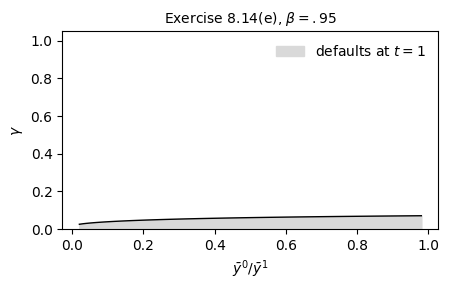

In [13]:
yb = np.array([1.0, 2.0]); P14 = np.array([[.7, .3], [.2, .8]]); b14, g14 = .95, 2.0


def weill_theta0(P, beta, gam, yb, s0=1, T=None):
    """Consumption share of type 0 (owner of the recession endowment); T=None: matrix inverse, else truncated sum."""
    y0 = np.array([yb[0], 0.0]); mu = yb**(-gam)
    if T is None:
        M = np.linalg.inv(np.eye(2) - beta * P)
        return (M[s0] @ (mu * y0)) / (M[s0] @ (mu * yb))
    num = den = 0.0; dist = np.eye(2)[s0]
    for k in range(T):
        num += beta**k * dist @ (mu * y0); den += beta**k * dist @ (mu * yb); dist = dist @ P
    return num / den


th0 = weill_theta0(P14, b14, g14, yb)
assert np.isclose(th0, weill_theta0(P14, b14, g14, yb, T=3000))
print(f"(a) theta0 = {th0:.6f}, theta1 = {1-th0:.6f}")
p1 = b14 * P14 @ yb**(-g14) / yb**(-g14)
print(f"(c) one-period bond price by state: {p1}; payoff matrix rank = {np.linalg.matrix_rank(np.c_[np.ones(2), p1])}")
assert abs(p1[0] - p1[1]) > 1e-3
# (d) alternation
Palt = np.array([[0, 1.], [1., 0]])
for gam in (0.5, 2.0, 6.0):
    th1 = 1 - weill_theta0(Palt, b14, gam, yb)
    assert np.isclose(th1, 1 / (1 + b14 * (yb[0] / yb[1])**(1 - gam)))
    print(f"(d) gamma = {gam}: theta1 = {th1:.4f}")
gstar = 1 + np.log(1 / b14) / np.log(yb[1] / yb[0])
assert np.isclose(1 - weill_theta0(Palt, b14, gstar, yb), .5)
print(f"(d) theta1 < 1/2 iff gamma > {gstar:.4f}")


def default_gain(gam, x, beta):
    """(e) V_default - V_stay at t=1 (times (1-gamma)(1-beta^2)/ybar1^(1-gamma)); >0 means default."""
    r = x**(1 - gam); th0 = beta * r / (1 + beta * r)
    return r - th0**(1 - gam) * (r + beta)


def default_gain_sum(gam, x, beta, T=4000):
    """Independent: truncated utility sums along the alternating path (ybar1 = 1, ybar0 = x)."""
    th0 = 1 - 1 / (1 + beta * x**(1 - gam))
    k = np.arange(T); y = np.where(k % 2 == 0, x, 1.0)       # t = 1, 2, ... : recession first
    own = np.where(k % 2 == 0, x, 0.0)
    u = lambda c: c**(1 - gam) / (1 - gam)
    return (beta**k @ u(own) - beta**k @ u(th0 * y)) * (1 - gam) * (1 - beta**2)


for gam, x in ((0.1, .5), (0.5, .5), (0.9, .2)):
    assert np.isclose(default_gain(gam, x, b14), default_gain_sum(gam, x, b14), atol=1e-8)
xs = np.linspace(.02, .98, 97)
gcrit = [brentq(lambda gm: default_gain(gm, x, b14), 1e-6, 1 - 1e-6) if default_gain(1 - 1e-6, x, b14) < 0 else 1.0 for x in xs]
print("(e) critical gamma (default iff gamma below) at ybar0/ybar1 = .2, .5, .8:",
      np.round(np.interp([.2, .5, .8], xs, gcrit), 4))
fig, ax = plt.subplots(figsize=(4.6, 3.0))
ax.fill_between(xs, 0, gcrit, color="0.85", label="defaults at $t=1$")
ax.plot(xs, gcrit, "k-", lw=1)
ax.set_xlabel(r"$\bar y^0/\bar y^1$"); ax.set_ylabel(r"$\gamma$"); ax.set_ylim(0, 1.05)
ax.set_title(r"Exercise 8.14(e), $\beta=.95$", fontsize=10); ax.legend(frameon=False, loc="upper right")
fig.tight_layout(); fig.savefig(FIG + "ls08_default.pdf"); plt.show()

## Exercise 8.15 --- Diverse beliefs, I

With $k=\mu_2/\mu_1$: $c^1_0=k/(1+k)$, $c^1(h_1)=k/(2+k)$, $c^1(h_2)=2k/(1+2k)$; consumer 1's budget gives
$k(3+\beta)=3+\beta$, so $k=1$ for every $\beta$. Check: `brentq` on the budget for several $\beta$; Arrow
budgets; Euler equations of both consumers under their own beliefs.

In [14]:
def budget15(k, beta):
    """Consumer 1's time-0 budget (value of consumption minus value of endowment), normalised q_0 = 1."""
    m1 = (1 + k) / k
    ch1, ch2 = k / (2 + k), 2 * k / (1 + 2 * k)
    q1 = (1 / 3) / (m1 * ch1); q2 = (2 / 3) / (m1 * ch2)          # q_t(h) / beta^t
    val_c = k / (1 + k) + beta / (1 - beta) * (q1 * ch1 + q2 * ch2)
    val_y = .5 + beta / (1 - beta) * q1 * 1.0
    return val_c - val_y


for beta in (.5, .9, .95):
    k = brentq(budget15, 1e-3, 1e3, args=(beta,))
    assert np.isclose(k, 1)
b15 = .95
c1h = np.array([1 / 3, 2 / 3]); c2h = 1 - c1h                    # t >= 1 on h1, h2
Qa = b15 * np.array([1 / 3, 2 / 3]) * .5 / c1h                    # consumer 1's Euler at t = 0
Qb = b15 * np.array([2 / 3, 1 / 3]) * .5 / c2h                    # consumer 2's Euler
assert np.allclose(Qa, Qb) and np.allclose(Qa, b15 / 2)
a1 = (c1h - np.array([1.0, 0.0])) / (1 - b15)                     # Upsilon^1 on h1, h2
assert np.isclose(.5 + Qa @ a1, .5)
print(f"k = 1; Arrow prices at t=0: {Qa}; c^1 on h1/h2 = {c1h}; a^1 = {a1}")

k = 1; Arrow prices at t=0: [0.475 0.475]; c^1 on h1/h2 = [0.333333 0.666667]; a^1 = [-13.333333  13.333333]


## Exercise 8.16 --- Diverse beliefs, II

$c^i_t=\dfrac{\lambda_i\pi^i_t}{\sum_j\lambda_j\pi^j_t}Y_t$, $q^0_t=\beta^t\dfrac{Y_0}{Y_t}\sum_i\omega_i\pi^i_t$,
$\omega_i=\lambda_i/\sum_j\lambda_j=c^i_0/Y_0$. Check on a random 3-agent, 4-history example: `scipy` maximises
the planner's date-1 problem; consumers' FOC with the formula prices; wealth $=\omega_iY_0/(1-\beta)$ in a
two-date truncation.

In [15]:
rng = np.random.default_rng(8)
I, H = 3, 4
pis = rng.dirichlet(np.ones(H), size=I)           # beliefs over 4 date-1 nodes
lamw = np.array([1.0, 2.0, 0.5]); Y1 = rng.uniform(.5, 2, H)
c_formula = lamw[:, None] * pis / (lamw @ pis) * Y1[None, :]
for h in range(H):                                 # planner node by node
    r = minimize(lambda x: -(lamw * pis[:, h]) @ np.log(x), np.full(I, Y1[h] / I), method="SLSQP",
                 bounds=[(1e-9, None)] * I, constraints=[{"type": "eq", "fun": lambda x: x.sum() - Y1[h]}],
                 options={"ftol": 1e-14})
    assert np.allclose(r.x, c_formula[:, h], atol=1e-5)
b16, Y0 = .9, 1.0
om = lamw / lamw.sum(); c0 = om * Y0
q1 = b16 * Y0 / Y1 * (om @ pis)                     # formula (e) at t = 1
for i in range(I):                                  # FOC beta pi^i / c^i_1 = mu_i q_1, mu_i = 1/c^i_0
    assert np.allclose(b16 * pis[i] / c_formula[i], q1 / c0[i])
print("(a) allocation at t=1:\n", c_formula, "\n(e) prices q_1:", q1)
# (f) lambda2/lambda1 -> infinity: prices -> consumer 2's beliefs
for L in (1, 10, 1e4):
    lw = np.array([1.0, L]); ww = lw / lw.sum()
    print(f"lambda2/lambda1 = {L:g}: weight of consumer 2 in prices = {ww[1]:.5f}")

(a) allocation at t=1:
 [[0.091544 0.268731 0.135351 0.820623]
 [0.674354 0.275476 1.433093 0.093116]
 [0.011199 0.24659  0.152297 0.220738]] 
(e) prices q_1: [0.268156 0.245679 0.174133 0.174263]
lambda2/lambda1 = 1: weight of consumer 2 in prices = 0.50000
lambda2/lambda1 = 10: weight of consumer 2 in prices = 0.90909
lambda2/lambda1 = 10000: weight of consumer 2 in prices = 0.99990


## Exercise 8.17 --- Diverse beliefs, III

Part I is 8.13 with log utility ($c=.5$). Part II: $\lambda=(.5+.1\beta)/(1+.1\beta)$;
$Q(0|1)=\beta(.4+.1\lambda)$, $Q(2|1)=\beta(.6-.1\lambda)$; $c^1$ on path 0: $.5\lambda/(.4+.1\lambda)$, path 2:
$.5\lambda/(.6-.1\lambda)$. Illustration $\beta=.95$. Checks: `brentq` on consumer 1's budget; consumer 2's
budget; Arrow budgets and both Euler equations at $t=0$.

In [16]:
b17 = .95
lam17 = (.5 + .1 * b17) / (1 + .1 * b17)


def budget17(lm, beta):
    """Consumer 1's time-0 budget: wealth lm/(1-beta) minus value of endowment (Y = 1, q_t(path) = beta^t (lm pi1 + (1-lm) pi2))."""
    return lm / (1 - beta) - (.5 + beta / (1 - beta) * (.5 * lm + .6 * (1 - lm)))


assert np.isclose(brentq(budget17, 1e-6, 1 - 1e-6, args=(b17,)), lam17)
Q17 = b17 * np.array([.5 * lam17 + .4 * (1 - lam17), .5 * lam17 + .6 * (1 - lam17)])   # to states 0, 2
c1p = np.array([.5 * lam17 / (.4 + .1 * lam17), .5 * lam17 / (.6 - .1 * lam17)])
c2p = 1 - c1p
assert np.allclose(Q17, b17 * np.array([.5, .5]) * lam17 / c1p)          # consumer 1's Euler
assert np.allclose(Q17, b17 * np.array([.4, .6]) * (1 - lam17) / c2p)    # consumer 2's Euler
a1 = (c1p - np.array([0.0, 1.0])) / (1 - b17)
assert np.isclose(lam17 + Q17 @ a1, .5)                                  # consumer 1's t=0 Arrow budget
a2 = (c2p - np.array([1.0, 0.0])) / (1 - b17)
assert np.isclose((1 - lam17) + Q17 @ a2, .5) and np.allclose(a1 + a2, 0)
print(f"lambda = {lam17:.6f}; Q(0|1), Q(2|1) = {Q17}; c1 on path 0/2 = {c1p}; a1 = {a1}")

lambda = 0.543379; Q(0|1), Q(2|1) = [0.431621 0.518379]; c1 on path 0/2 = [0.59799  0.497908]; a1 = [ 11.959799 -10.041841]


## Exercises 8.18--8.19 --- Dogmatic diverse beliefs

Pareto: $c^1_0=\lambda$, $c^1=1$ on history 1, $0$ on history 2. 8.18: no-trade equilibrium, $Q(1|.5)=Q(0|.5)=.5\beta$.
8.19: each consumer sells the claims on the history he rules out up to the natural debt limit $1/(1-\beta)$.
Checks: Euler equations where beliefs are positive, sign of the value of disbelieved claims, budgets.

In [17]:
b18 = .95
Qt0 = np.array([.5 * b18, .5 * b18])        # prices of claims on s1 = 1 (history 1), s1 = 0 (history 2)
# 8.18: endowments already Pareto optimal (lambda = .5)
assert np.isclose(Qt0[0], b18 * 1 * .5 / 1)      # consumer 1: beta * prob 1 * c0/c1
assert np.isclose(Qt0[1], b18 * 1 * .5 / 1)      # consumer 2 on history 2
# 8.19: consumer 1 holds a(1) = 1/(1-b), a(0) = -1/(1-b) (debt limit: his endowment 1 forever on history 2)
a1_19 = np.array([1, -1]) / (1 - b18)
A1_hist2 = 1 / (1 - b18)
assert np.isclose(-a1_19[1], A1_hist2)                   # natural debt limit binds
assert np.isclose(.5 + Qt0 @ a1_19, .5)                  # t = 0 budget: c0 = .5
assert np.isclose(1 + b18 * a1_19[0], 0 + a1_19[0])      # history 1, t>=1: c=1, y=0, roll over
assert np.isclose(0 + b18 * a1_19[1], 1 + a1_19[1])      # history 2, t>=1: c=0, y=1, service debt
print("8.18/8.19 equilibria verified; Arrow prices at t=0:", Qt0)

8.18/8.19 equilibria verified; Arrow prices at t=0: [0.475 0.475]


## Exercise 8.20 --- Risk-free bonds

$Q(s'|s)=\beta P(s'|s)/\lambda(s')$, $R(s)=1/[\beta\sum_{s'}P(s'|s)/\lambda(s')]$. Numbers of part (f).

In [18]:
P20 = np.array([[1, 0], [.5, .5]]); b20, z20 = .95, .02
lam20 = np.array([1, 1 + z20])
Q20 = kernel(b20, P20, np.ones(2)) / lam20[None, :]
R20 = 1 / Q20.sum(1)
assert np.isclose(R20[0], 1 / .95) and np.isclose(R20[1], 1 / (.95 * (.5 + .5 / 1.02)))
print(f"R(s=1) = {R20[0]:.6f}, R(s=2) = {R20[1]:.6f}")

R(s=1) = 1.052632, R(s=2) = 1.063054


## Exercise 8.21 --- Relative entropy

$m\log m\ge m-1$ and $\int mf=1$. Checks on a grid and on random discrete densities.

In [19]:
m = np.linspace(1e-8, 50, 200001)
assert np.all(m * np.log(m) - (m - 1) >= -1e-12)
for _ in range(1000):
    f, ft = rng.dirichlet(np.ones(6)), rng.dirichlet(np.ones(6))
    mm = ft / f
    ent = np.sum(np.log(ft / f) * ft)
    assert np.isclose(ent, np.sum(mm * np.log(mm) * f)) and ent >= 0 and np.isclose(np.sum(mm * f), 1)
print("entropy >= 0 on 1000 random pairs")

entropy >= 0 on 1000 random pairs


## Exercise 8.22 --- Heterogeneous beliefs again

$\tilde Q(s'|s^t)=\beta\dfrac{y_t}{y_{t+1}}\dfrac{\lambda\pi^1(s')+(1-\lambda)L_t\pi^2(s')}{\lambda+(1-\lambda)L_t}$.
Illustration: $\tilde\alpha=\alpha_2=.5$, $\alpha_1=.7$, $\lambda=.5$, $\beta=.95$. Checks: formula vs direct
Euler equation of consumer 2; $\frac1t\log L_t\to\mathrm{ent}(\pi^2,\pi^1)$; kernel converges to the
representative-agent kernel.

ent(pi2, pi1) = 0.08718


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


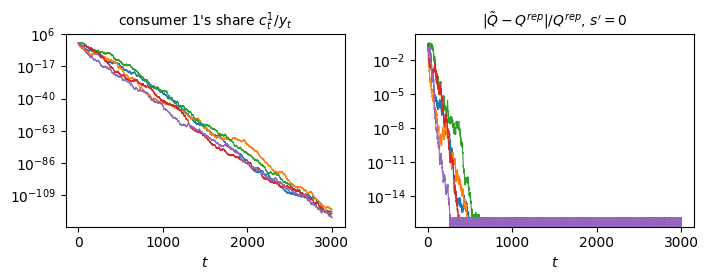

In [20]:
at, a1b, lm22, b22 = .5, .7, .5, .95
pi2 = np.array([at, 1 - at]); pi1 = np.array([a1b, 1 - a1b]); y22 = np.array([1.0, .5])
ent21 = pi2 @ np.log(pi2 / pi1)
Tn, npaths = 3000, 5
rng22 = np.random.default_rng(22)
fig, axs = plt.subplots(1, 2, figsize=(7.2, 2.9))
for p in range(npaths):
    s = (rng22.random(Tn) > at).astype(int)            # s = 0 with prob .5
    logL = np.cumsum(np.log(pi2[s] / pi1[s]))
    L = np.exp(np.minimum(logL, 700))
    share1 = lm22 / (lm22 + (1 - lm22) * L)
    # kernel for s' = 0 at each t, formula vs consumer-2 Euler
    sp = 0
    Qf = b22 * y22[s] / y22[sp] * (lm22 * pi1[sp] + (1 - lm22) * L * pi2[sp]) / (lm22 + (1 - lm22) * L)
    c2 = (1 - share1) * y22[s]
    Lnext = L * pi2[sp] / pi1[sp]
    c2n = (1 - lm22) * Lnext / (lm22 + (1 - lm22) * Lnext) * y22[sp]
    ok = L < 1e12
    assert np.allclose(Qf[ok], (b22 * pi2[sp] * c2 / c2n)[ok])
    Qrep = b22 * y22[s] / y22[sp] * pi2[sp]
    assert abs(logL[-1] / Tn - ent21) < .03 and abs(Qf[-1] - Qrep[-1]) < 1e-10
    axs[0].semilogy(np.arange(1, Tn + 1), share1, lw=.8)
    axs[1].semilogy(np.arange(1, Tn + 1), abs(Qf - Qrep) / Qrep, lw=.8)
print(f"ent(pi2, pi1) = {ent21:.5f}")
axs[0].set_xlabel("$t$"); axs[0].set_title("consumer 1's share $c^1_t/y_t$", fontsize=10)
axs[1].set_xlabel("$t$"); axs[1].set_title(r"$|\tilde Q-Q^{rep}|/Q^{rep}$, $s'=0$", fontsize=10)
fig.tight_layout(); fig.savefig(FIG + "ls08_beliefs.pdf"); plt.show()

## Exercise 8.23 --- Recursive Pareto problem with heterogeneous beliefs

Illustration: $u_1=\log c$, $u_2=\log(1-c)$, $S=2$, $\Pi^1=(.3,.7)$, $\Pi^2=(.5,.5)$, $\beta=.9$. With
$r_s=\Pi^1_s/\Pi^2_s$ the FOCs give $c_s=\theta r_s/(1+\theta r_s)$ and $\theta'=\theta r_s$. The values
$v(\theta)$, $P(\theta)$ are computed by truncated binomial sums (independent of the Bellman equation), then
checked: Bellman equations hold, $dP/dv=-\theta$ (envelope), $w_s>v$ iff $r_s>1$.

theta = 0.5: v = -8.2958, P = -3.2609, c_s = [0.230769 0.411765], w_s = [-11.0691, -6.7399]


theta = 1.0: v = -5.3255, P = -5.3658, c_s = [0.375    0.583333], w_s = [-7.4258, -4.2048]


theta = 3.0: v = -2.3497, P = -10.4706, c_s = [0.642857 0.807692], w_s = [-3.4946, -1.7842]


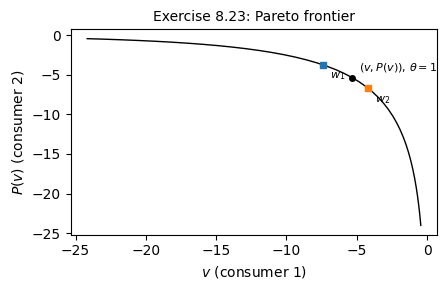

In [21]:
Pi1, Pi2, b23 = np.array([.3, .7]), np.array([.5, .5]), .9
r23 = Pi1 / Pi2
T23 = 350


def values(theta):
    """v(theta), P(theta) by summing over dates t and binomial counts k of state-1 draws (t+1 draws by date t)."""
    v = Pv = 0.0
    for tt in range(T23):
        k = np.arange(tt + 2)
        lx = np.log(theta) + k * np.log(r23[0]) + (tt + 1 - k) * np.log(r23[1])
        lc, l1c = -np.logaddexp(0, -lx), -np.logaddexp(0, lx)
        v += b23**tt * binom.pmf(k, tt + 1, Pi1[0]) @ lc
        Pv += b23**tt * binom.pmf(k, tt + 1, Pi2[0]) @ l1c
    return v, Pv


for theta in (.5, 1.0, 3.0):
    v, Pv = values(theta)
    cs = theta * r23 / (1 + theta * r23)
    ws = [values(theta * rs) for rs in r23]
    assert np.isclose(v, Pi1 @ (np.log(cs) + b23 * np.array([w[0] for w in ws])))
    assert np.isclose(Pv, Pi2 @ (np.log(1 - cs) + b23 * np.array([w[1] for w in ws])))
    h = 1e-4
    vp, Pp = values(theta * np.exp(h)); vm, Pm = values(theta * np.exp(-h))
    assert np.isclose((Pp - Pm) / (vp - vm), -theta, rtol=1e-5)
    assert all((w[0] > v) == (rs > 1) for w, rs in zip(ws, r23))
    print(f"theta = {theta}: v = {v:.4f}, P = {Pv:.4f}, c_s = {cs}, w_s = {[round(float(w[0]), 4) for w in ws]}")
th_grid = np.exp(np.linspace(-3, 3, 41))
VP = np.array([values(x) for x in th_grid])
fig, ax = plt.subplots(figsize=(4.6, 3.0))
ax.plot(VP[:, 0], VP[:, 1], "k-", lw=1)
v, Pv = values(1.0); ws = [values(r) for r in r23]
ax.plot(v, Pv, "ko", ms=4); ax.annotate(r"$(v,P(v))$, $\theta=1$", (v, Pv), xytext=(5, 5), textcoords="offset points", fontsize=8)
for (wv, wP), s in zip(ws, (1, 2)):
    ax.plot(wv, wP, "s", ms=4); ax.annotate(f"$w_{s}$", (wv, wP), xytext=(5, -10), textcoords="offset points", fontsize=8)
ax.set_xlabel("$v$ (consumer 1)"); ax.set_ylabel("$P(v)$ (consumer 2)")
ax.set_title("Exercise 8.23: Pareto frontier", fontsize=10)
fig.tight_layout(); fig.savefig(FIG + "ls08_pareto.pdf"); plt.show()

## Exercise 8.24 --- Recovering probabilities from prices

$Q=\beta D^{-1}PD$, $D=\mathrm{diag}(y^{-\gamma})$: $\beta$ is the Perron root of $Q$, its eigenvector is
$\propto y^{\gamma}$, and $P_{ij}=Q_{ij}z_j/(\beta z_i)$. Illustration: $\beta=.95$, $\gamma=3$, $y=(1,1.1)$,
$P=[.9\ .1;\ .4\ .6]$. Check (b): both rows of $Q$ from row 1 of $Q$ and $Q^2$.

In [22]:
b24, g24 = .95, 3.0; y24 = np.array([1, 1.1]); P24 = np.array([[.9, .1], [.4, .6]])
Q24 = kernel(b24, P24, y24**(-g24))
assert np.allclose(hstep_rec(Q24, 3), np.linalg.matrix_power(Q24, 3))


def recover(Q):
    """Exercise 8.24(d): (beta, P) from Q via the Perron root and right eigenvector."""
    w, V = np.linalg.eig(Q)
    k = np.argmax(w.real); z = np.abs(V[:, k].real)
    beta = w[k].real
    return beta, Q * z[None, :] / (beta * z[:, None]), z


bh, Ph, z = recover(Q24)
assert np.isclose(bh, b24) and np.allclose(Ph, P24) and np.isclose(z[1] / z[0], (y24[1] / y24[0])**g24)
row1, row1sq = Q24[0], (Q24 @ Q24)[0]
row2 = (row1sq - Q24[0, 0] * row1) / Q24[0, 1]
assert np.allclose(row2, Q24[1])
print("Q =\n", Q24, f"\nrecovered beta = {bh:.6f}, P =\n{Ph}")

Q =
 [[0.855    0.071375]
 [0.50578  0.57    ]] 
recovered beta = 0.950000, P =
[[0.9 0.1]
 [0.4 0.6]]


## Exercise 8.25 --- Recovering probabilities, II (growth)

$Q=\beta P\Lambda$, $\Lambda=\mathrm{diag}(\bar\lambda^{-\gamma})$. From $Q$ alone $x=Q^{-1}\mathbf1$ pins the
products $\beta\bar\lambda_j^{-\gamma}=1/x_j$ and $P=Q\,\mathrm{diag}(x)$, but not $\beta$: any $\beta'$ with
$\bar\lambda_j'^{-\gamma}=1/(\beta'x_j)$ gives the same $Q$. Illustration $\beta=.95$, $\gamma=2$,
$\bar\lambda=(.97,1.03)$, $P=[.8\ .2;\ .1\ .9]$.

In [23]:
b25, g25 = .95, 2.0; lam25 = np.array([.97, 1.03]); P25 = np.array([[.8, .2], [.1, .9]])
Q25 = b25 * P25 * lam25[None, :]**(-g25)
x = np.linalg.solve(Q25, np.ones(2))
assert np.allclose(Q25 * x[None, :], P25)
for bp in (.90, .99):
    lamp = (1 / (bp * x))**(-1 / g25)
    Qp = bp * (Q25 * x[None, :]) * lamp[None, :]**(-g25)
    assert np.allclose(Qp, Q25)
    print(f"beta' = {bp}: lambda' = {lamp} reproduces Q exactly")
# with lambda known, beta is identified from row sums of Q Lambda^{-1}
assert np.allclose((Q25 / lam25[None, :]**(-g25)).sum(1), b25)

beta' = 0.9: lambda' = [0.944129 1.002528] reproduces Q exactly
beta' = 0.99: lambda' = [0.990211 1.051461] reproduces Q exactly


## Exercise 8.26 --- Recovering probabilities, III (risk-free bonds only)

$p^t_{t+h}=e_i'Q^h\mathbf1$. Cayley--Hamilton: $p_{h+2}=\tau p_{h+1}-\delta p_h$ ($p_0=1$), $\tau=\beta(P_{11}+P_{22})$,
$\delta=\beta^2(P_{11}+P_{22}-1)$, so $p_4$ is redundant; $\beta$ = larger root of $x^2-\tau x+\delta$; $p_1$ then
gives one equation in $(P_{11},\kappa)$. Illustration: $\beta=.95$, $P_{11}=.9$, $P_{22}=.6$,
$\kappa=(c(1)/c(2))^{-\gamma}=1.2$; a second parameter set with the same $p_1..p_4$ is constructed.

In [24]:
def bonds(beta, P11, P22, kap, i=0, H=4):
    """Risk-free bond prices p_h, h=1..H, at state i; kap = (c(1)/c(2))^(-gamma)."""
    P = np.array([[P11, 1 - P11], [1 - P22, P22]])
    Q = beta * P * np.array([[1, 1 / kap], [kap, 1]])
    return np.array([np.linalg.matrix_power(Q, h)[i].sum() for h in range(1, H + 1)])


b26, P11, P22, kap = .95, .9, .6, 1.2
p = bonds(b26, P11, P22, kap)
tau = b26 * (P11 + P22); dlt = b26**2 * (P11 + P22 - 1)
pp = np.r_[1, p]
assert np.allclose(pp[2:], tau * pp[1:-1] - dlt * pp[:-2])
tau_h, dlt_h = np.linalg.solve([[pp[1], -1], [pp[2], -pp[1]]], [pp[2], pp[3]])
beta_h = (tau_h + np.sqrt(tau_h**2 - 4 * dlt_h)) / 2
assert np.isclose(beta_h, b26)
sig = tau_h / beta_h
P11b = .8; P22b = sig - P11b
kapb = (1 - P11b) / (p[0] / b26 - P11b)          # from p1 = beta (P11 + (1-P11)/kap)
pb = bonds(b26, P11b, P22b, kapb)
assert np.allclose(pb, p)
print(f"p_1..p_4 = {p}\nalso generated by P11 = {P11b}, P22 = {P22b:.4f}, kappa = {kapb:.6f} (true: .9, .6, 1.2)")

p_1..p_4 = [0.934167 0.879937 0.832368 0.789053]
also generated by P11 = 0.8, P22 = 0.7000, kappa = 1.090909 (true: .9, .6, 1.2)


## Exercise 8.27 --- Corners in a Markov economy

$c^2(s)=\min\{Y(s),\bar c\}$, $c^1=Y-c^2$, where $\bar c$ solves type 2's budget
$e_{s_0}'(I-\beta P)^{-1}[y^2/c^2]=1/(1-\beta)$; $Q(s'|s)=\beta P(s'|s)c^2(s)/c^2(s')$; type 1's marginal value
of wealth $\varphi(s)=\bar c/c^2(s)\ge1$. Pareto weight: $(1-\alpha)/\alpha=\bar c$.
Illustration: $\lambda=.8$, $\delta=.6$, $\beta=.9$, $s_0=\bar s_1$; case A: $y^1=(1,1.5)$, $y^2=(.5,.3)$ (never
binds); case B: $y^1=(.05,1.5)$, $y^2=(.3,1)$ (binds in $\bar s_1$). Checks: Arrow budgets of both types in every
state with $a=\Upsilon$; type 1's Euler equation with $\varphi$; KKT signs.

In [25]:
P27 = np.array([[.8, .2], [.4, .6]]); b27 = .9
M27 = np.linalg.inv(np.eye(2) - b27 * P27)


def corners(y1, y2, s0=0):
    """Exercise 8.27(c): (cbar, c1, c2, Q) of the sequential Arrow equilibrium with zero initial wealth."""
    Y = y1 + y2
    g = lambda cb: M27[s0] @ (y2 / np.minimum(Y, cb)) - 1 / (1 - b27)
    cb = brentq(g, 1e-6, 1e3)
    c2 = np.minimum(Y, cb); c1 = Y - c2
    return cb, c1, c2, kernel(b27, P27, 1 / c2)


for name, y1, y2 in (("A", np.array([1, 1.5]), np.array([.5, .3])), ("B", np.array([.05, 1.5]), np.array([.3, 1.0]))):
    cb, c1, c2, Q = corners(y1, y2)
    Ups1 = np.linalg.solve(np.eye(2) - Q, c1 - y1); Ups2 = np.linalg.solve(np.eye(2) - Q, c2 - y2)
    for s in range(2):
        assert np.isclose(c1[s] + Q[s] @ Ups1, y1[s] + Ups1[s]) and np.isclose(c2[s] + Q[s] @ Ups2, y2[s] + Ups2[s])
    assert np.isclose(Ups1[0], 0, atol=1e-10) and np.allclose(Ups1 + Ups2, 0)
    phi = cb / c2
    assert np.allclose(Q * phi[:, None], b27 * P27 * phi[None, :])    # type 1's Euler with phi
    assert np.all(phi >= 1 - 1e-12) and np.allclose(phi[c1 > 1e-12], 1)
    A1 = np.linalg.solve(np.eye(2) - Q, y1); A2 = np.linalg.solve(np.eye(2) - Q, y2)
    alpha = 1 / (1 + cb)
    print(f"case {name}: cbar = {cb:.6f} (alpha = {alpha:.4f}); c1 = {c1}, c2 = {c2}; phi = {phi}\n"
          f"   Q =\n{Q}\n   Upsilon1 = {Ups1}; debt limits A1 = {A1}, A2 = {A2}")
    if name == "A":
        assert np.all(c1 > 0) and np.isclose(cb, (1 - b27) * M27[0] @ y2) and np.allclose(Q, b27 * P27)
    else:
        assert c1[0] == 0 and c1[1] > 0

case A: cbar = 0.443750 (alpha = 0.6926); c1 = [1.05625 1.35625], c2 = [0.44375 0.44375]; phi = [1. 1.]
   Q =
[[0.72 0.18]
 [0.36 0.54]]
   Upsilon1 = [-0.     -0.3125]; debt limits A1 = [11.40625 12.1875 ], A2 = [4.4375 4.125 ]
case B: cbar = 0.732558 (alpha = 0.5772); c1 = [0.       1.767442], c2 = [0.35     0.732558]; phi = [2.093023 1.      ]
   Q =
[[0.72     0.086   ]
 [0.753488 0.54    ]]
   Upsilon1 = [-0.        0.581395]; debt limits A1 = [2.375    7.151163], A2 = [3.5      7.906977]


## Exercise 8.28 --- Recovering probabilities, IV

$Q^{(1)}_{11}=\beta\lambda$, $Q^{(1)}_{12}=\beta(1-\lambda)\kappa$, $Q^{(1)}_{21}=\beta(1-\delta)/\kappa$, $Q^{(1)}_{22}=\beta\delta$,
$\kappa=(\bar y_2/\bar y_1)^{-\gamma}$; $Q^{(2)}=Q^{(1)}Q^{(1)}$. Inverse problem: with $a=Q^{(1)}_{11}$, $b=Q^{(1)}_{12}$,
$c=Q^{(2)}_{11}$, $d=Q^{(2)}_{12}$, $e=d/b-a=\beta\delta$, $\beta$ is the larger root of
$x^2-(a+e)x+ae-(c-a^2)=0$. Illustration $\lambda=.85$, $\delta=.7$, $\beta=.96$, $\gamma=2$, $\bar y=(1,1.2)$.
Check: Perron root of 8.24.

In [26]:
lm28, dl28, b28, g28 = .85, .7, .96, 2.0; y28 = np.array([1, 1.2])
P28 = np.array([[lm28, 1 - lm28], [1 - dl28, dl28]])
Q1 = kernel(b28, P28, y28**(-g28)); Q2 = Q1 @ Q1
kap = (y28[1] / y28[0])**(-g28)
assert np.allclose(Q1, b28 * np.array([[lm28, (1 - lm28) * kap], [(1 - dl28) / kap, dl28]]))
assert np.isclose(Q2[0, 0], b28**2 * (lm28**2 + (1 - lm28) * (1 - dl28)))
assert np.isclose(Q2[0, 1], b28**2 * (1 - lm28) * (lm28 + dl28) * kap)
a, b_, c, d = Q1[0, 0], Q1[0, 1], Q2[0, 0], Q2[0, 1]
e = d / b_ - a
roots = np.roots([1, -(a + e), a * e - (c - a**2)])
bh = roots.max()
assert np.isclose(bh, b28) and roots.min() < min(a, e)
assert np.isclose(bh, recover(Q1)[0])
print(f"observed [Q1(1,1), Q1(1,2), Q2(1,1), Q2(1,2)] = {np.round([a, b_, c, d], 6)}")
print(f"recovered beta = {bh:.6f}, lambda = {a/bh:.6f}, delta = {e/bh:.6f}, kappa = {b_/(bh*(1-a/bh)):.6f}; other root {roots.min():.6f}")

observed [Q1(1,1), Q1(1,2), Q2(1,1), Q2(1,2)] = [0.816    0.1      0.707328 0.1488  ]
recovered beta = 0.960000, lambda = 0.850000, delta = 0.700000, kappa = 0.694444; other root 0.528000
